# Brain Tumor Segmentation (PyTorch)

Brain tumor segmentation is a core task in medical image analysis, where the goal is to automatically identify and label different tumor sub-regions from 3D MRI scans. Accurate segmentation helps clinicians with diagnosis, treatment planning, and disease monitoring. In this tutorial, we focus on multimodal MRI-based brain tumor segmentation using the widely adopted **BraTS** (**Brain Tumor Segmentation**) dataset.

This notebook is a **PyTorch rewrite** of the original Keras/`medicai` tutorial. Since `medicai` is a Keras library, we use [**MONAI**](https://monai.io/) — the standard PyTorch medical-imaging framework — for the model (`SwinUNETR`), transforms, Dice loss/metrics, and sliding-window inference. The data pipeline is built on top of `torch.utils.data.Dataset` / `DataLoader`, reading the original `.nii` files directly via MONAI's `LoadImaged`.

## The BraTS Dataset

The **BraTS** dataset provides multimodal 3D brain MRI scans, released as NIfTI files (`.nii.gz`). For each patient, four MRI modalities are available:

- **T1** – native T1-weighted MRI
- **T1Gd** – post-contrast T1-weighted MRI
- **T2** – T2-weighted MRI
- **T2-FLAIR** – Fluid Attenuated Inversion Recovery MRI

These scans are collected using different scanners and clinical protocols from 19 institutions. More details can be found in the official [BraTS documentation](https://www.med.upenn.edu/cbica/brats2020/data.html).

## Segmentation Labels

The segmentation masks contain the following tumor sub-regions:

- **NCR / NET (label 1)** – Necrotic and non-enhancing tumor core
- **ED (label 2)** – Peritumoral edema
- **ET (label 4)** – GD-enhancing tumor
- **0** – Background (non-tumor tissue)

The data are released after preprocessing: all modalities are **co-registered**, resampled to `1 mm³` isotropic resolution, and **skull-stripped**.

# Dataset Format

The BraTS scans are provided as `.nii` files ([Kaggle](https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation/)), one folder per patient case containing `flair`, `t1`, `t1ce`, `t2`, and `seg` (label) volumes. We load these directly with MONAI's `LoadImaged` (backed by `nibabel`) — no intermediate TFRecord conversion is needed.

Since the official `BraTS2020_ValidationData` folder ships without segmentation labels, we hold out a slice of cases from the labeled `BraTS2020_TrainingData` for validation.

---

# What This Tutorial Covers

1. **Loading the Dataset** — read TFRecord files (`image`, `label`, `affine`) and build PyTorch `DataLoader`s.
2. **Medical Image Preprocessing** — apply MONAI transforms.
3. **Model Building** — 3D `SwinUNETR` from MONAI with 4 input channels / 3 output channels.
4. **Loss and Metrics** — `DiceCELoss` and `DiceMetric`.
5. **Model Evaluation** — `sliding_window_inference` on full 3D volumes with per-class Dice.
6. **Visualization of Results**.

---

In [1]:
# Install dependencies
# MONAI provides SwinUNETR, transforms, DiceCELoss, DiceMetric, sliding_window_inference,
# and NIfTI loading (via nibabel) — no TensorFlow needed for this NIfTI-based pipeline.
!pip install "monai[nibabel,tqdm,einops]" -qU

from IPython.display import clear_output
clear_output()

In [2]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import monai
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    CropForegroundd,
    RandSpatialCropd,
    RandFlipd,
    NormalizeIntensityd,
    RandShiftIntensityd,
    MapTransform,
    EnsureTyped,
    ConcatItemsd,
)
from monai.data import decollate_batch

print(
    f"torch version:  {torch.__version__}\n"
    f"monai version:  {monai.__version__}\n"
    f"cuda available: {torch.cuda.is_available()}\n"
)

torch version:  2.10.0+cu128
monai version:  1.6.0
cuda available: True



In [3]:
# reproducibility
monai.utils.set_determinism(seed=101)
torch.manual_seed(101)
np.random.seed(101)

# device / multi-GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
total_device = torch.cuda.device_count() if torch.cuda.is_available() else 1

print("Device:       ", device)
print("Total devices:", total_device)

Device:        cuda
Total devices: 2


# Create Multi-label Brain Tumor Labels

The BraTS task is formulated as a **multi-label** segmentation problem. The label combinations define the clinical regions of interest:

```shell
- Tumor Core (TC):    label = 1 or 4        -> channel 0
- Whole Tumor (WT):   label = 1 or 2 or 4   -> channel 1
- Enhancing Tumor (ET): label = 4           -> channel 2
```

In PyTorch/MONAI we implement this as a dictionary `MapTransform` that converts a single-channel integer label into a 3-channel binary target. This is the direct equivalent of the original `process_brats_targets` + `LambdaTransform`.

In [4]:
class ConvertToMultiChannelBratsd(MapTransform):
    """
    Convert BraTS labels to a 3-channel multi-label target.

    Output channels:
    - Channel 0 (TC): Tumor core       (labels 1 or 4)
    - Channel 1 (WT): Whole tumor      (labels 1, 2, or 4)
    - Channel 2 (ET): Enhancing tumor  (label 4)
    """
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            label = d[key]
            # squeeze a trailing/leading channel dim if present -> (D, H, W)
            if label.ndim == 4 and label.shape[0] == 1:
                label = label[0]

            tc = (label == 1) | (label == 4)
            wt = (label == 1) | (label == 2) | (label == 4)
            et = (label == 4)

            d[key] = np.stack(
                [tc, wt, et], axis=0
            ).astype(np.float32)  # (3, D, H, W), channel-first for MONAI
        return d

# Transformation

MONAI transforms operate on **channel-first** tensors, i.e. `(channel, depth, height, width)`. Each case's four `.nii` modality files are loaded independently with `LoadImaged`, given a channel dim with `EnsureChannelFirstd`, then merged into a single 4-channel image with `ConcatItemsd`.

The pipeline mirrors the original exactly: multi-label conversion, foreground crop, random `96³` spatial crop, three random flips, non-zero channel-wise intensity normalization, and a random intensity shift. Validation only does the label conversion and normalization.

In [5]:
modality_keys = ["flair", "t1", "t1ce", "t2"]

train_transform = Compose([
    LoadImaged(keys=modality_keys + ["label"]),
    EnsureChannelFirstd(keys=modality_keys + ["label"]),
    ConcatItemsd(keys=modality_keys, name="image", dim=0),
    ConvertToMultiChannelBratsd(keys=["label"]),
    CropForegroundd(
        keys=["image", "label"],
        source_key="image",
        k_divisible=[96, 96, 96],
        allow_smaller=True,
    ),
    RandSpatialCropd(
        keys=["image", "label"],
        roi_size=(96, 96, 96),
        random_size=False,
    ),
    RandFlipd(keys=["image", "label"], spatial_axis=0, prob=0.5),
    RandFlipd(keys=["image", "label"], spatial_axis=1, prob=0.5),
    RandFlipd(keys=["image", "label"], spatial_axis=2, prob=0.5),
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    RandShiftIntensityd(keys=["image"], offsets=0.10, prob=1.0),
    EnsureTyped(keys=["image", "label"]),
])

val_transform = Compose([
    LoadImaged(keys=modality_keys + ["label"]),
    EnsureChannelFirstd(keys=modality_keys + ["label"]),
    ConcatItemsd(keys=modality_keys, name="image", dim=0),
    ConvertToMultiChannelBratsd(keys=["label"]),
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    EnsureTyped(keys=["image", "label"]),
])

# Building the File List

Each BraTS case is a folder containing five `.nii` files: `flair`, `t1`, `t1ce`, `t2`, and `seg` (the label). We scan the training directory and build one dict per case mapping each modality key to its file path — this dict is exactly what `LoadImaged` expects.

In [6]:
def build_case_dicts(training_root):
    """Scan a MICCAI_BraTS2020_TrainingData-style folder and build one dict per case.

    Each returned dict has keys: flair, t1, t1ce, t2, label (file paths).
    """
    case_dirs = sorted(glob.glob(os.path.join(training_root, "BraTS20_Training_*")))
    data_dicts = []
    for case_dir in case_dirs:
        case_id = os.path.basename(case_dir)
        d = {
            "flair": os.path.join(case_dir, f"{case_id}_flair.nii"),
            "t1": os.path.join(case_dir, f"{case_id}_t1.nii"),
            "t1ce": os.path.join(case_dir, f"{case_id}_t1ce.nii"),
            "t2": os.path.join(case_dir, f"{case_id}_t2.nii"),
            "label": os.path.join(case_dir, f"{case_id}_seg.nii"),
        }
        if all(os.path.exists(p) for p in d.values()):
            data_dicts.append(d)
    return data_dicts

# Dataset & Dataloader

`BratsNiftiDataset` wraps a list of case dicts (from `build_case_dicts`). Each `__getitem__` call runs the full MONAI transform pipeline: it loads the 4 modality `.nii` files + label lazily via `LoadImaged`, concatenates modalities into a `(4, D, H, W)` image, and converts the label into the `(3, D, H, W)` multi-channel target.

Because files are loaded lazily per-sample (not all materialized in memory up front, unlike the old TFRecord version), this scales to the full ~369-case training set without excessive RAM use. Because samples vary in spatial size before cropping, we keep `val_batch_size = 1` for full-volume validation.

In [7]:
class BratsNiftiDataset(Dataset):
    """Wraps a list of case dicts (paths to .nii files) and applies a MONAI transform."""

    def __init__(self, data_dicts, transform):
        self.data_dicts = data_dicts
        self.transform = transform

    def __len__(self):
        return len(self.data_dicts)

    def __getitem__(self, idx):
        data = self.transform(self.data_dicts[idx])
        return data["image"], data["label"]

In [8]:
train_root = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

# Note: the official BraTS2020_ValidationData folder has NO segmentation labels
# (no `_seg.nii` file), so it can't be used for Dice-based validation here.
# We instead hold out a slice of the labeled TrainingData for validation.
all_cases = build_case_dicts(train_root)

train_datalist = all_cases[:-20]
val_datalist = all_cases[-20:]
print(len(train_datalist), len(val_datalist))
print(val_datalist[0])

348 20
{'flair': '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_349/BraTS20_Training_349_flair.nii', 't1': '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_349/BraTS20_Training_349_t1.nii', 't1ce': '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_349/BraTS20_Training_349_t1ce.nii', 't2': '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_349/BraTS20_Training_349_t2.nii', 'label': '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_349/BraTS20_Training_349_seg.nii'}


In [9]:
# batch size scales with device count, matching the original notebook
train_batch = 1 * total_device

train_dataset = BratsNiftiDataset(train_datalist, transform=train_transform)
val_dataset = BratsNiftiDataset(val_datalist, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
)

print("train samples:", len(train_dataset), " | val samples:", len(val_dataset))

train samples: 348  | val samples: 20


In [10]:
# sanity check one validation volume (no random crop -> full size)
val_x, val_y = val_dataset[0]
test_image = val_x.numpy()   # (4, D, H, W)
test_mask = val_y.numpy()    # (3, D, H, W)
print(test_image.shape, test_mask.shape, np.unique(test_mask))
print(test_image.min(), test_image.max())

(4, 240, 240, 155) (3, 240, 240, 155) [0. 1.]
-3.1942935 15.360751


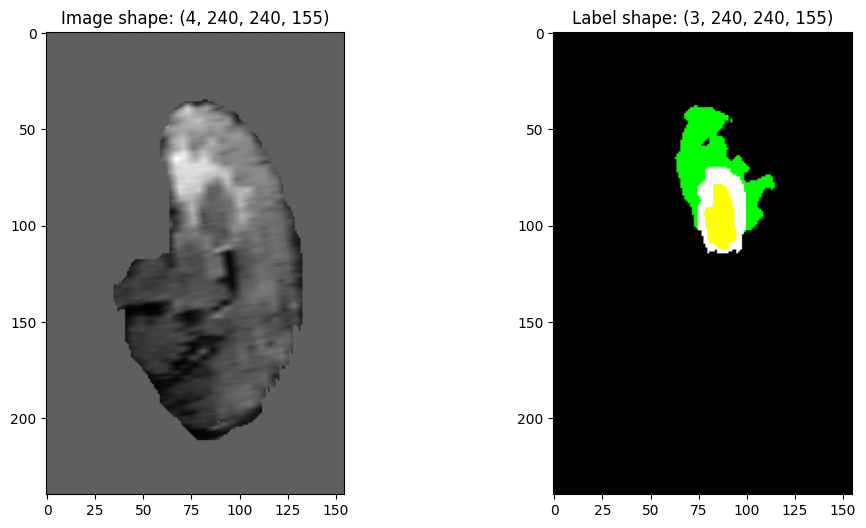

In [11]:
# channel-first -> pick a mid axial slice for display
mid = test_image.shape[1] // 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(test_image[0, mid], cmap='gray')          # flair channel
ax1.set_title(f'Image shape: {test_image.shape}')
ax2.imshow(np.moveaxis(test_mask[:, mid], 0, -1))    # (3, H, W) -> (H, W, 3)
ax2.set_title(f'Label shape: {test_mask.shape}')
plt.show()

image shape: (4, 240, 240, 155)


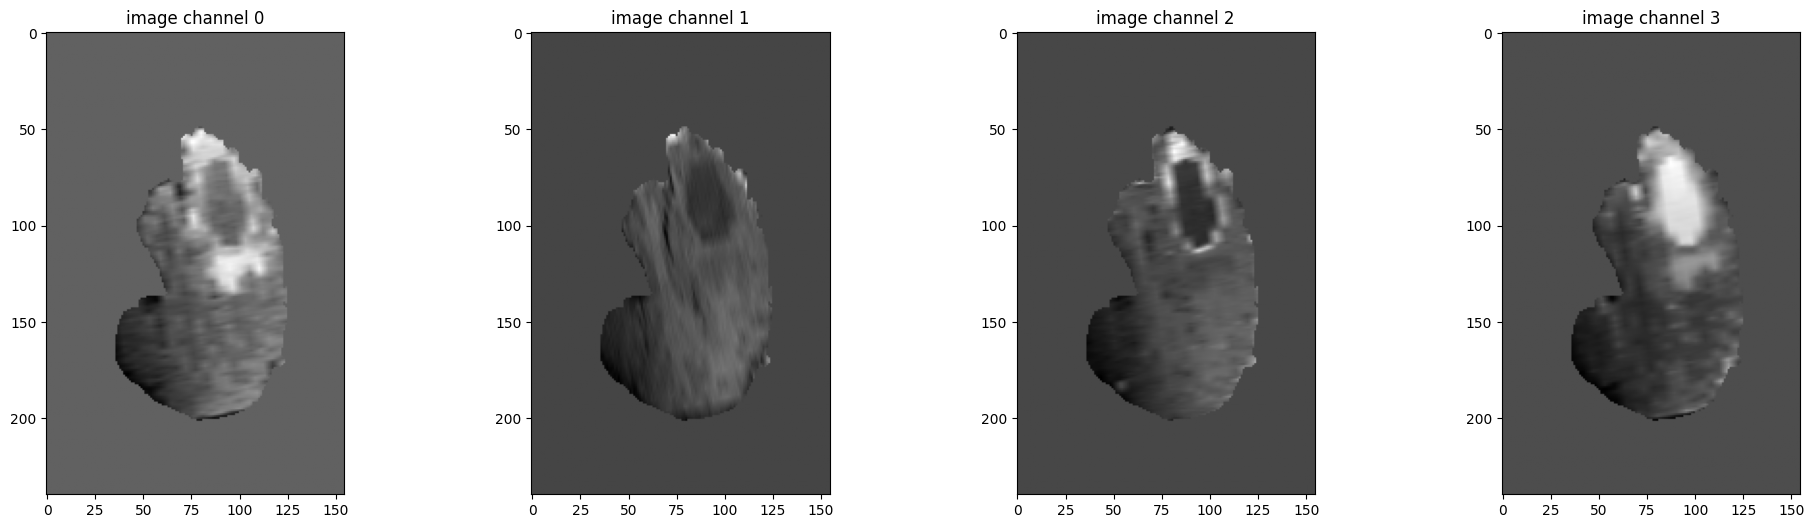

label shape: (3, 240, 240, 155)


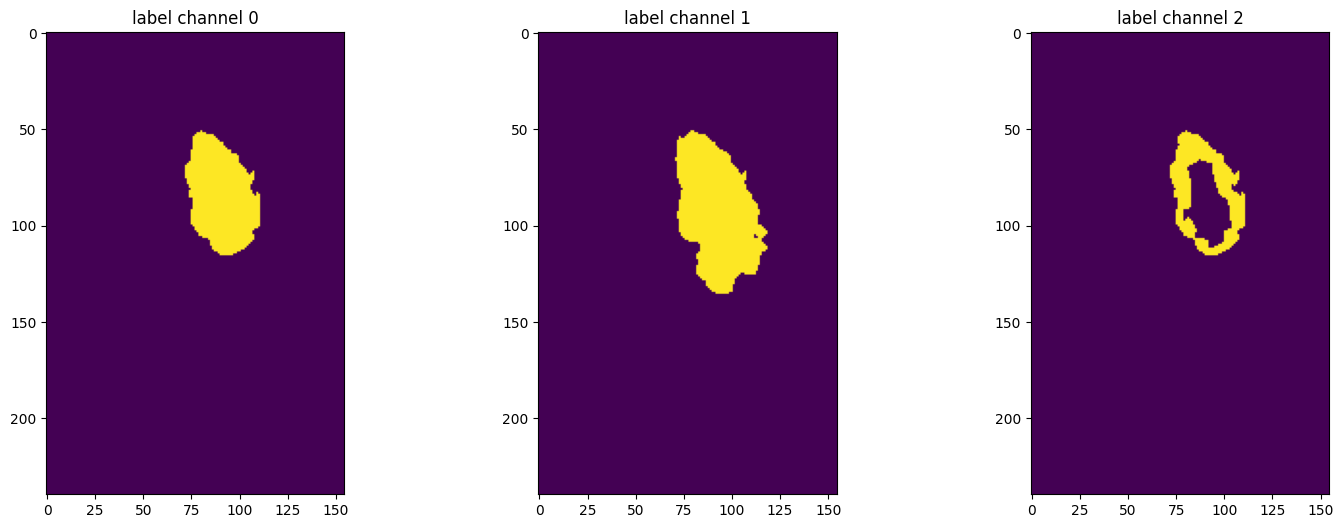

In [12]:
print(f"image shape: {test_image.shape}")
plt.figure("image", (24, 6))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.title(f"image channel {i}")
    plt.imshow(test_image[i, 80], cmap="gray")
plt.show()

print(f"label shape: {test_mask.shape}")
plt.figure("label", (18, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f"label channel {i}")
    plt.imshow(test_mask[i, 80])
plt.show()

# Model

We use the 3D [`SwinUNETR`](https://arxiv.org/abs/2201.01266) architecture from MONAI. BraTS provides four input modalities (`flair`, `t1`, `t1ce`, `t2`), so the model has **4 input channels** and **3 output channels**.

The original Keras `classifier_activation=None` (logits output) maps to MONAI's default `SwinUNETR`, which returns raw logits. We wrap the model in `nn.DataParallel` when more than one GPU is available (the PyTorch equivalent of the Keras `MirroredStrategy` / `DataParallel` distribution).

In [13]:
num_classes = 3
epochs = 30
roi_size = (96, 96, 96)

def get_model():
    model = SwinUNETR(
        in_channels=4,
        out_channels=num_classes,
        feature_size=48,     # 'tiny' Swin configuration
        use_checkpoint=True,
    )
    return model

model = get_model().to(device)

if total_device > 1:
    model = nn.DataParallel(model)

# optimizer + loss (DiceCELoss on sigmoid logits == BinaryDiceCELoss(from_logits=True))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
loss_fn = DiceCELoss(sigmoid=True)

# per-class + mean Dice metrics (ignore_empty matches the Keras metric)
dice_metric = DiceMetric(include_background=True, reduction="mean", ignore_empty=True)
dice_metric_batch = DiceMetric(include_background=True, reduction="mean_batch", ignore_empty=True)

n_params = sum(p.numel() for p in model.parameters())
print(f"SwinUNETR parameters: {n_params/1e6:.1f}M")

SwinUNETR parameters: 62.2M


In [14]:
# post-processing for metric computation: sigmoid -> threshold 0.5
def post_pred(logits):
    return (torch.sigmoid(logits) > 0.5).float()

# Training

We train with sliding-window validation every `interval` epochs, saving the best model by mean validation Dice — the PyTorch equivalent of the original `SlidingWindowInferenceCallback`.

Set more epochs for better optimization.

In [15]:
def validate(model, loader, interval_label=""):
    """Full-volume sliding-window inference + per-class Dice on the validation set."""
    model.eval()
    dice_metric.reset()
    dice_metric_batch.reset()
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = sliding_window_inference(
                inputs=x,
                roi_size=roi_size,
                sw_batch_size=4 * total_device,
                predictor=model,
                overlap=0.5,
                mode="gaussian",
            )
            preds = post_pred(logits)
            dice_metric(y_pred=preds, y=y)
            dice_metric_batch(y_pred=preds, y=y)

    mean_dice = dice_metric.aggregate().item()
    per_class = dice_metric_batch.aggregate()  # tensor of length num_classes
    return mean_dice, per_class.cpu().numpy()

In [16]:
from tqdm.auto import tqdm

best_dice = -1.0
best_path = "brats.model.weights.pt"
interval = 5
history = []

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{epochs}", leave=False)
    for step, (x, y) in enumerate(pbar, start=1):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{epoch_loss / step:.4f}")

    epoch_loss /= max(1, len(train_loader))
    row = {"epoch": epoch, "loss": epoch_loss}

    # periodic validation (sliding-window)
    if epoch % interval == 0 or epoch == epochs:
        mean_dice, per_class = validate(model, val_loader)
        row.update({
            "val_dice": mean_dice,
            "val_dice_tc": float(per_class[0]),
            "val_dice_wt": float(per_class[1]),
            "val_dice_et": float(per_class[2]),
        })
        if mean_dice > best_dice:
            best_dice = mean_dice
            # save underlying module state when wrapped in DataParallel
            state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save(state, best_path)
        print(
            f"epoch {epoch:3d} | loss {epoch_loss:.4f} | "
            f"val_dice {mean_dice:.4f} "
            f"(tc {per_class[0]:.4f}, wt {per_class[1]:.4f}, et {per_class[2]:.4f})"
        )
    else:
        print(f"epoch {epoch:3d} | loss {epoch_loss:.4f}")

    history.append(row)

epoch 1/30:   0%|          | 0/174 [00:00<?, ?it/s]

epoch   1 | loss 0.9580


epoch 2/30:   0%|          | 0/174 [00:00<?, ?it/s]

epoch   2 | loss 0.9132


epoch 3/30:   0%|          | 0/174 [00:00<?, ?it/s]

...

epoch  28 | loss 0.4727


epoch 29/30:   0%|          | 0/174 [00:00<?, ?it/s]

epoch  29 | loss 0.4541


epoch 30/30:   0%|          | 0/174 [00:00<?, ?it/s]

epoch  30 | loss 0.4632 | val_dice 0.8412 (tc 0.7633, wt 0.9046, et 0.8558)


In [17]:
his_csv = pd.DataFrame(history)
his_csv.to_csv('brats.history.csv', index=False)
print(his_csv.columns.tolist())
his_csv.head()

['epoch', 'loss', 'val_dice', 'val_dice_tc', 'val_dice_wt', 'val_dice_et']


,epoch,loss,val_dice,val_dice_tc,val_dice_wt,val_dice_et
0,1,0.957969,NaN,NaN,NaN,NaN
1,2,0.913196,NaN,NaN,NaN,NaN
2,3,0.878737,NaN,NaN,NaN,NaN
3,4,0.846822,NaN,NaN,NaN,NaN
4,5,0.808847,0.389046,0.387155,0.529602,0.250383


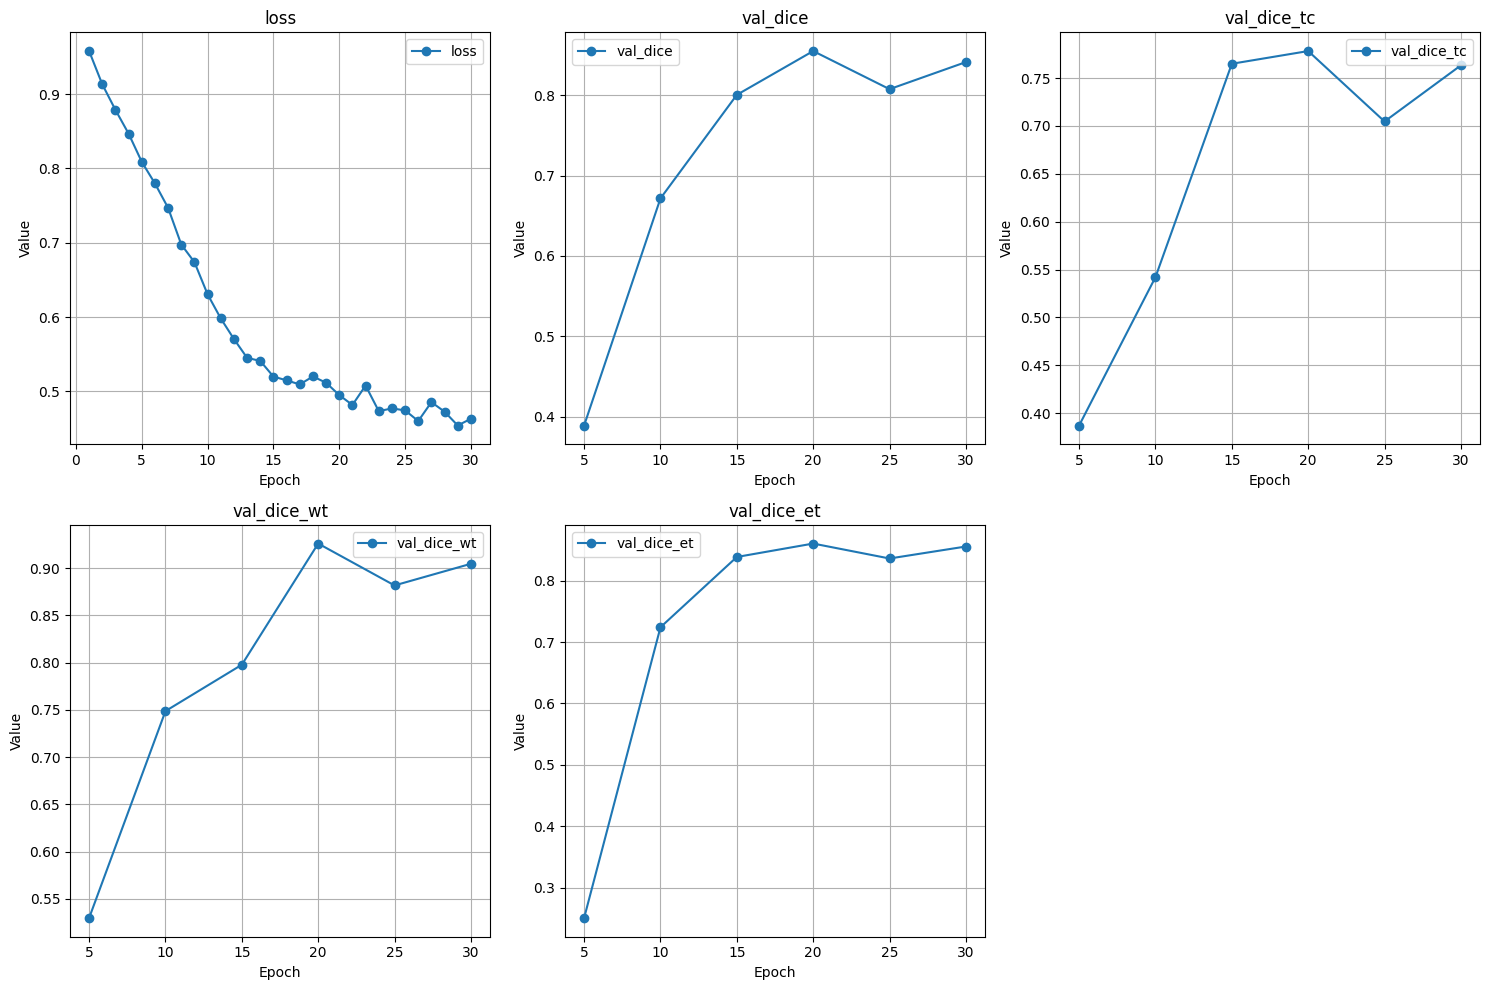

In [18]:
def plot_training_history(history_df):
    metrics = [c for c in history_df.columns if c != "epoch"]
    n_metrics = len(metrics)
    n_rows = 2
    n_cols = (n_metrics + 1) // 2

    plt.figure(figsize=(5 * n_cols, 5 * n_rows))
    for idx, metric in enumerate(metrics):
        plt.subplot(n_rows, n_cols, idx + 1)
        s = history_df[["epoch", metric]].dropna()
        plt.plot(s["epoch"], s[metric], label=metric, marker='o')
        plt.title(metric)
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.grid(True)
        plt.legend()
    plt.tight_layout()
    plt.show()

plot_training_history(his_csv)

# Evaluation

Load the best checkpoint and evaluate per-class Dice using sliding-window inference over the full validation volumes.

In [19]:
# reload best weights
state = torch.load(best_path, map_location=device)
if isinstance(model, nn.DataParallel):
    model.module.load_state_dict(state)
else:
    model.load_state_dict(state)

mean_dice, per_class = validate(model, val_loader)

print(f"Dice Score:        {mean_dice:.4f}")
print(f"Dice Score on TC:  {per_class[0]:.4f}")
print(f"Dice Score on WT:  {per_class[1]:.4f}")
print(f"Dice Score on ET:  {per_class[2]:.4f}")

Dice Score:        0.8549
Dice Score on TC:  0.7782
Dice Score on WT:  0.9261
Dice Score on ET:  0.8606


# Analyse and Visualize

We run inference on one validation case and reconstruct the original integer label map (`1`/`2`/`4`) from the 3-channel prediction, matching the original notebook's overlap logic.

In [20]:
# grab the raw (untransformed) sample for reference visualization
import nibabel as nib

raw_case = val_datalist[0]
orig_image = np.stack(
    [nib.load(raw_case[k]).get_fdata() for k in modality_keys], axis=-1
)  # (H, W, D, 4)
orig_label = nib.load(raw_case["label"]).get_fdata()  # (H, W, D)

orig_image = np.transpose(orig_image, (2, 1, 0, 3))  # (D, H, W, 4) for display
orig_label = np.transpose(orig_label, (2, 1, 0))      # (D, H, W)
print(orig_image.shape, orig_label.shape, np.unique(orig_label))

(155, 240, 240, 4) (155, 240, 240) [0. 1. 2. 4.]


In [21]:
# preprocess through the val transform and run sliding-window inference
pre_x, pre_y = val_dataset[0]  # channel-first tensors
pre_label = np.moveaxis(pre_y.numpy(), 0, -1)  # (D, H, W, 3) for display

model.eval()
with torch.no_grad():
    x = pre_x.unsqueeze(0).to(device)  # (1, 4, D, H, W)
    logits = sliding_window_inference(
        x, roi_size, sw_batch_size=4 * total_device,
        predictor=model, overlap=0.5, mode="gaussian",
    )
    y_pred_prob = torch.sigmoid(logits).squeeze(0).cpu().numpy()  # (3, D, H, W)

segment = (y_pred_prob > 0.5).astype(int)
segment = np.moveaxis(segment, 0, -1)  # (D, H, W, 3)
print(segment.shape, np.unique(segment))

(240, 240, 155, 3) [0 1]


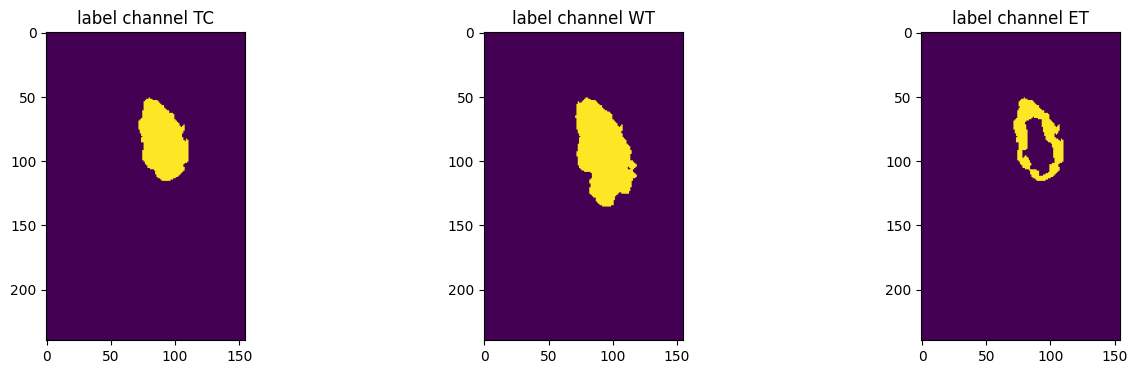

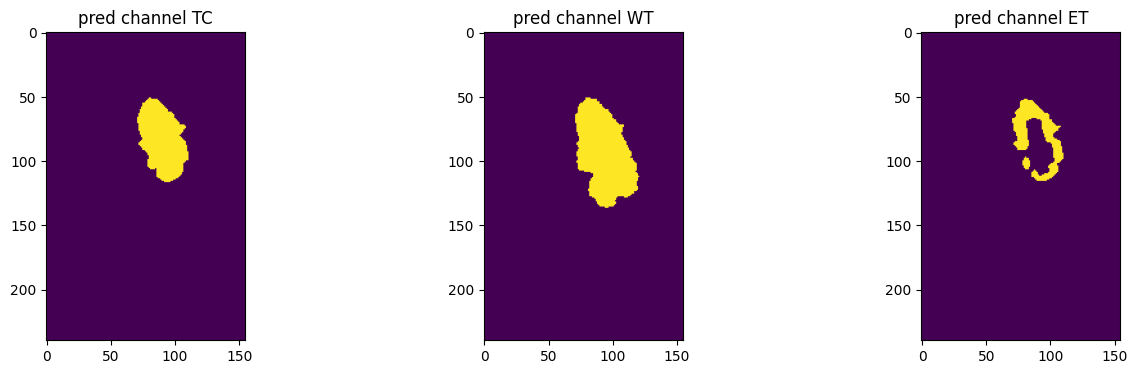

In [22]:
label_map = {0: 'TC', 1: 'WT', 2: 'ET'}

plt.figure(figsize=(16, 4))
for i in range(pre_label.shape[-1]):
    plt.subplot(1, 3, i + 1)
    plt.title(f"label channel {label_map[i]}")
    plt.imshow(pre_label[80, :, :, i])
plt.show()

plt.figure(figsize=(16, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f"pred channel {label_map[i]}")
    plt.imshow(segment[80, :, :, i])
plt.show()

In [23]:
# reconstruct integer label map from the 3 binary channels
prediction = np.zeros(segment.shape[:3], dtype='float32')
prediction[segment[..., 1] == 1] = 2   # WT -> edema
prediction[segment[..., 0] == 1] = 1   # TC -> necrotic/non-enhancing
prediction[segment[..., 2] == 1] = 4   # ET -> enhancing

print('label     ', orig_label.shape, np.unique(orig_label))
print('predicted ', prediction.shape, np.unique(prediction))

label      (155, 240, 240) [0. 1. 2. 4.]
predicted  (240, 240, 155) [0. 1. 2. 4.]


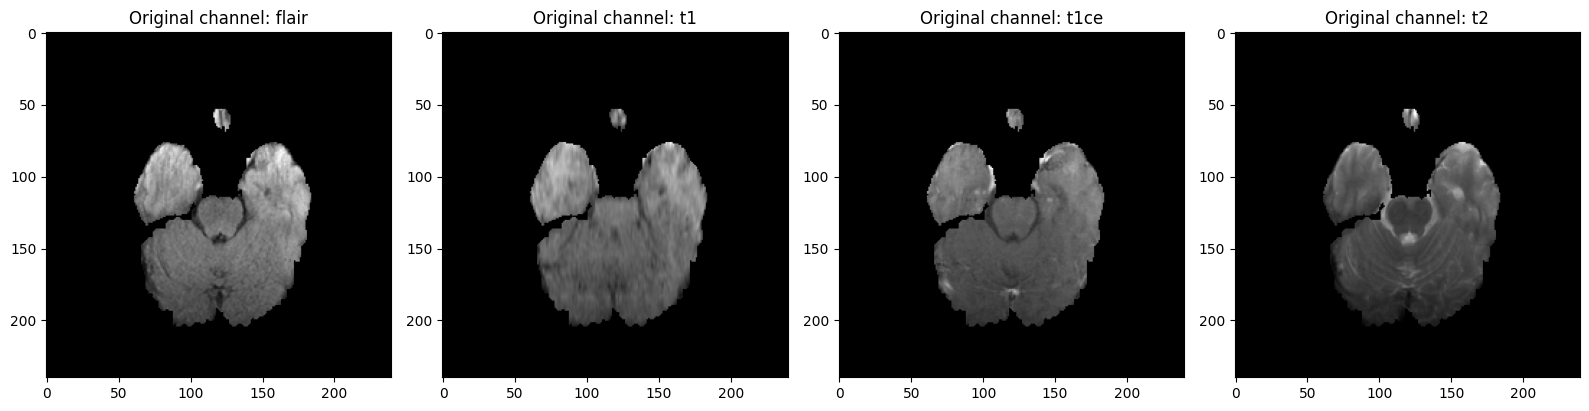

In [24]:
slice_map = {0: 'flair', 1: 't1', 2: 't1ce', 3: 't2'}

plt.figure(figsize=(16, 4))
for i in range(orig_image.shape[-1]):
    plt.subplot(1, 4, i + 1)
    plt.title(f"Original channel: {slice_map[i]}")
    plt.imshow(orig_image[60, :, :, i], cmap='gray')
plt.tight_layout()
plt.show()

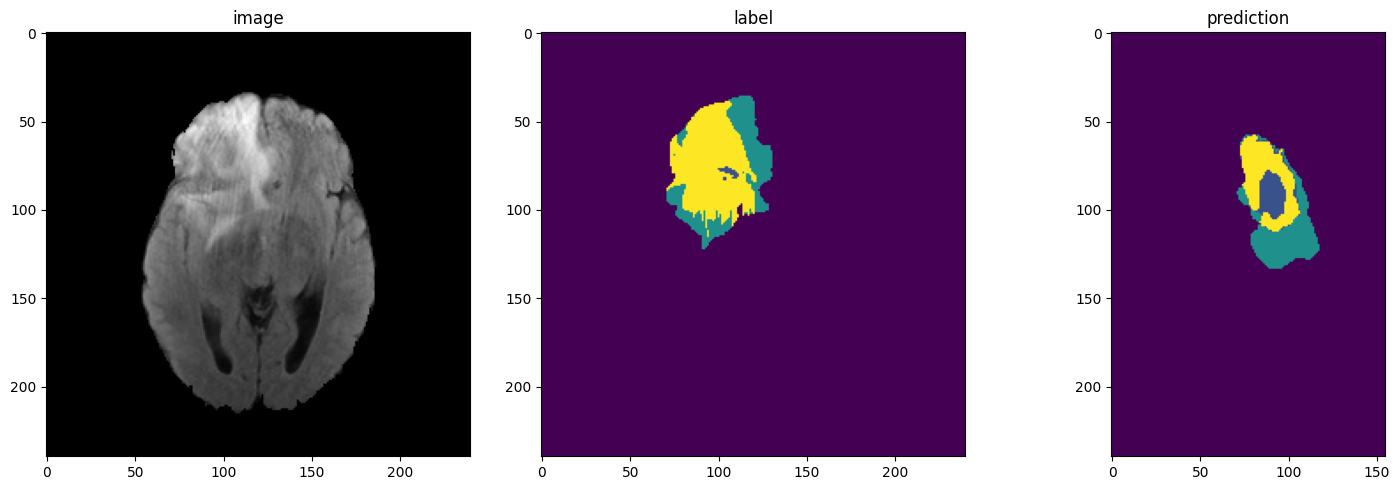

In [25]:
slice_num = 75

plt.figure("image", (15, 5))
plt.subplot(1, 3, 1)
plt.title("image")
plt.imshow(orig_image[slice_num, :, :, 0], cmap='gray')

plt.subplot(1, 3, 2)
plt.title("label")
plt.imshow(orig_label[slice_num, :, :])

plt.subplot(1, 3, 3)
plt.title("prediction")
plt.imshow(prediction[slice_num, :, :])

plt.tight_layout()
plt.show()

## Notes on the Keras → PyTorch port

| Original (Keras / `medicai`)                    | PyTorch equivalent (this notebook)                          |
|-------------------------------------------------|-------------------------------------------------------------|
| `KERAS_BACKEND`, `keras.distribution`           | `torch.device`, `nn.DataParallel`                           |
| `medicai.transforms.*` (`Compose`, crops, flips)| `monai.transforms.*` dictionary transforms                  |
| `LambdaTransform(process_brats_targets)`        | `ConvertToMultiChannelBratsd` (`MapTransform`)              |
| `tf.data` pipeline + `.map`                      | `torch.utils.data.Dataset` + `DataLoader` + `LoadImaged`     |
| `SwinUNETR(encoder_name='swin_tiny_v2')`        | `monai.networks.nets.SwinUNETR(feature_size=48)`            |
| `BinaryDiceCELoss(from_logits=True)`            | `monai.losses.DiceCELoss(sigmoid=True)`                     |
| `BinaryDiceMetric(...)`                         | `monai.metrics.DiceMetric` (mean + `mean_batch` per-class)  |
| `SlidingWindowInferenceCallback`                | manual `sliding_window_inference` in the `validate()` loop  |
| `keras.optimizers.AdamW`                        | `torch.optim.AdamW`                                         |
| channel-**last** `(D, H, W, C)`                 | channel-**first** `(C, D, H, W)`                            |

**Key behavioral differences to be aware of:**

- MONAI's `SwinUNETR` uses `feature_size` (48 ≈ the "tiny" config) rather than a named `encoder_name`. Adjust to `feature_size=24` for a smaller/faster model.
- The original label was channel-**last**; MONAI is channel-**first**, so all transpose/`moveaxis` calls differ accordingly.
- `DiceMetric(reduction="mean_batch")` returns per-class scores in channel order `[TC, WT, ET]`, matching the original `target_class_ids=[0]/[1]/[2]`.
- This version loads `.nii` files directly with MONAI's `LoadImaged` (backed by `nibabel`) — no TFRecord/TensorFlow dependency at all.
- The official `BraTS2020_ValidationData` has no labels, so "validation" here means a held-out slice of the labeled `BraTS2020_TrainingData`.

## Additional Resources

- [MONAI BraTS tutorial](https://github.com/Project-MONAI/tutorials/blob/main/3d_segmentation/brats_segmentation_3d.ipynb)
- [MONAI SwinUNETR docs](https://docs.monai.io/en/stable/networks.html#swinunetr)